In [454]:
# Defining the libraries

In [412]:
import seaborn as sns
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler, StandardScaler
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.metrics import r2_score,mean_squared_error

In [455]:
# Load the dataset

In [413]:
df = sns.load_dataset('titanic')

In [414]:
df

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
886,0,2,male,27.0,0,0,13.0000,S,Second,man,True,NaN,Southampton,no,True
887,1,1,female,19.0,0,0,30.0000,S,First,woman,False,B,Southampton,yes,True
888,0,3,female,NaN,1,2,23.4500,S,Third,woman,False,NaN,Southampton,no,False
889,1,1,male,26.0,0,0,30.0000,C,First,man,True,C,Cherbourg,yes,True


In [456]:
# Check the columns, shape, null values

In [415]:
df.columns

Index(['survived', 'pclass', 'sex', 'age', 'sibsp', 'parch', 'fare',
       'embarked', 'class', 'who', 'adult_male', 'deck', 'embark_town',
       'alive', 'alone'],
      dtype='object')

In [416]:
df.shape

(891, 15)

In [417]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   survived     891 non-null    int64   
 1   pclass       891 non-null    int64   
 2   sex          891 non-null    object  
 3   age          714 non-null    float64 
 4   sibsp        891 non-null    int64   
 5   parch        891 non-null    int64   
 6   fare         891 non-null    float64 
 7   embarked     889 non-null    object  
 8   class        891 non-null    category
 9   who          891 non-null    object  
 10  adult_male   891 non-null    bool    
 11  deck         203 non-null    category
 12  embark_town  889 non-null    object  
 13  alive        891 non-null    object  
 14  alone        891 non-null    bool    
dtypes: bool(2), category(2), float64(2), int64(4), object(5)
memory usage: 80.7+ KB


In [418]:
df.isnull().sum()

survived         0
pclass           0
sex              0
age            177
sibsp            0
parch            0
fare             0
embarked         2
class            0
who              0
adult_male       0
deck           688
embark_town      2
alive            0
alone            0
dtype: int64

In [457]:
# Visualizing the countplot for survived column

<Axes: xlabel='survived', ylabel='count'>

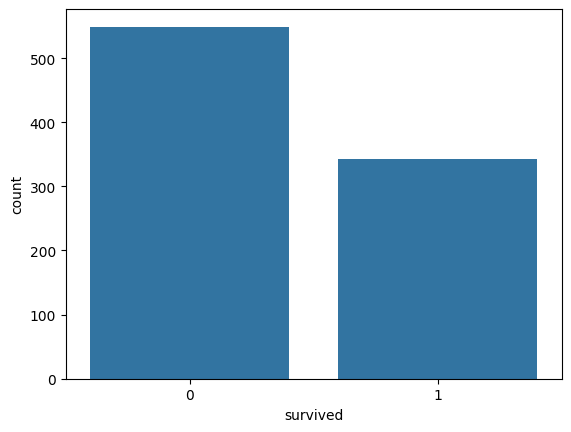

In [419]:
sns.countplot(x='survived',data=df)

<Axes: xlabel='pclass', ylabel='count'>

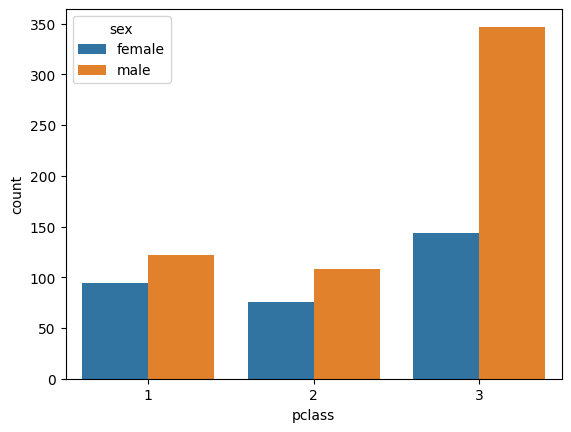

In [420]:
sns.countplot(x='pclass',hue='sex',data=df)

<Axes: xlabel='survived', ylabel='count'>

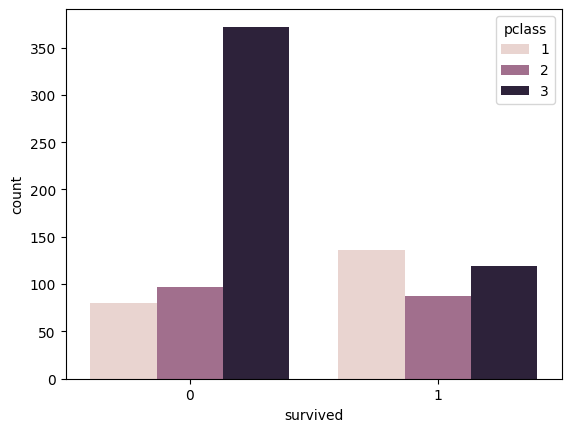

In [421]:
sns.countplot(x='survived',hue='pclass',data=df)

In [422]:
df.isnull()[:10]

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False
1,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False
3,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False
5,False,False,False,True,False,False,False,False,False,False,False,True,False,False,False
6,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
7,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False
8,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False
9,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False


In [423]:
df.columns

Index(['survived', 'pclass', 'sex', 'age', 'sibsp', 'parch', 'fare',
       'embarked', 'class', 'who', 'adult_male', 'deck', 'embark_town',
       'alive', 'alone'],
      dtype='object')

In [424]:
df.drop(['class','who','adult_male','deck','embark_town','alive','alone'],axis=1,inplace=True)

In [425]:
df.isnull()[:10]

,survived,pclass,sex,age,sibsp,parch,fare,embarked
0,False,False,False,False,False,False,False,False
1,False,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False,False
3,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False
5,False,False,False,True,False,False,False,False
6,False,False,False,False,False,False,False,False
7,False,False,False,False,False,False,False,False
8,False,False,False,False,False,False,False,False
9,False,False,False,False,False,False,False,False


In [426]:
df.isnull().sum()

survived      0
pclass        0
sex           0
age         177
sibsp         0
parch         0
fare          0
embarked      2
dtype: int64

In [458]:
# One-hot label encoding

In [427]:
sx= pd.get_dummies(df['sex'],drop_first=True,dtype=int)

In [428]:
sx

,male
0,1
1,0
2,0
3,0
4,1
...,...
886,1
887,0
888,0
889,1


In [429]:
df

,survived,pclass,sex,age,sibsp,parch,fare,embarked
0,0,3,male,22.0,1,0,7.2500,S
1,1,1,female,38.0,1,0,71.2833,C
2,1,3,female,26.0,0,0,7.9250,S
3,1,1,female,35.0,1,0,53.1000,S
4,0,3,male,35.0,0,0,8.0500,S
...,...,...,...,...,...,...,...,...
886,0,2,male,27.0,0,0,13.0000,S
887,1,1,female,19.0,0,0,30.0000,S
888,0,3,female,NaN,1,2,23.4500,S
889,1,1,male,26.0,0,0,30.0000,C


In [430]:
embrk = pd.get_dummies(df['embarked'],drop_first=True,dtype=int)

In [431]:
embrk

,Q,S
0,0,1
1,0,0
2,0,1
3,0,1
4,0,1
...,...,...
886,0,1
887,0,1
888,0,1
889,0,0


In [432]:
df.drop(['sex','embarked'],axis=1)

,survived,pclass,age,sibsp,parch,fare
0,0,3,22.0,1,0,7.2500
1,1,1,38.0,1,0,71.2833
2,1,3,26.0,0,0,7.9250
3,1,1,35.0,1,0,53.1000
4,0,3,35.0,0,0,8.0500
...,...,...,...,...,...,...
886,0,2,27.0,0,0,13.0000
887,1,1,19.0,0,0,30.0000
888,0,3,NaN,1,2,23.4500
889,1,1,26.0,0,0,30.0000


In [433]:
df

,survived,pclass,sex,age,sibsp,parch,fare,embarked
0,0,3,male,22.0,1,0,7.2500,S
1,1,1,female,38.0,1,0,71.2833,C
2,1,3,female,26.0,0,0,7.9250,S
3,1,1,female,35.0,1,0,53.1000,S
4,0,3,male,35.0,0,0,8.0500,S
...,...,...,...,...,...,...,...,...
886,0,2,male,27.0,0,0,13.0000,S
887,1,1,female,19.0,0,0,30.0000,S
888,0,3,female,NaN,1,2,23.4500,S
889,1,1,male,26.0,0,0,30.0000,C


In [459]:
# adding the new columns

In [434]:
df = pd.concat([df,sx,embrk],axis=1)

In [435]:
df

,survived,pclass,sex,age,sibsp,parch,fare,embarked,male,Q,S
0,0,3,male,22.0,1,0,7.2500,S,1,0,1
1,1,1,female,38.0,1,0,71.2833,C,0,0,0
2,1,3,female,26.0,0,0,7.9250,S,0,0,1
3,1,1,female,35.0,1,0,53.1000,S,0,0,1
4,0,3,male,35.0,0,0,8.0500,S,1,0,1
...,...,...,...,...,...,...,...,...,...,...,...
886,0,2,male,27.0,0,0,13.0000,S,1,0,1
887,1,1,female,19.0,0,0,30.0000,S,0,0,1
888,0,3,female,NaN,1,2,23.4500,S,0,0,1
889,1,1,male,26.0,0,0,30.0000,C,1,0,0


In [436]:
pcl = pd.get_dummies(df['pclass'],drop_first=True,dtype=int)

In [437]:
pcl

,2,3
0,0,1
1,0,0
2,0,1
3,0,0
4,0,1
...,...,...
886,1,0
887,0,0
888,0,1
889,0,0


In [438]:
df['age'] = df['age'].fillna(df['age'].mean())
df

,survived,pclass,sex,age,sibsp,parch,fare,embarked,male,Q,S
0,0,3,male,22.000000,1,0,7.2500,S,1,0,1
1,1,1,female,38.000000,1,0,71.2833,C,0,0,0
2,1,3,female,26.000000,0,0,7.9250,S,0,0,1
3,1,1,female,35.000000,1,0,53.1000,S,0,0,1
4,0,3,male,35.000000,0,0,8.0500,S,1,0,1
...,...,...,...,...,...,...,...,...,...,...,...
886,0,2,male,27.000000,0,0,13.0000,S,1,0,1
887,1,1,female,19.000000,0,0,30.0000,S,0,0,1
888,0,3,female,29.699118,1,2,23.4500,S,0,0,1
889,1,1,male,26.000000,0,0,30.0000,C,1,0,0


In [439]:
df = df.drop(['pclass'],axis=1)
df = pd.concat([df,pcl],axis=1)
df

,survived,sex,age,sibsp,parch,fare,embarked,male,Q,S,2,3
0,0,male,22.000000,1,0,7.2500,S,1,0,1,0,1
1,1,female,38.000000,1,0,71.2833,C,0,0,0,0,0
2,1,female,26.000000,0,0,7.9250,S,0,0,1,0,1
3,1,female,35.000000,1,0,53.1000,S,0,0,1,0,0
4,0,male,35.000000,0,0,8.0500,S,1,0,1,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...
886,0,male,27.000000,0,0,13.0000,S,1,0,1,1,0
887,1,female,19.000000,0,0,30.0000,S,0,0,1,0,0
888,0,female,29.699118,1,2,23.4500,S,0,0,1,0,1
889,1,male,26.000000,0,0,30.0000,C,1,0,0,0,0


In [440]:
df.drop(['sex','embarked'],axis=1,inplace=True)
df

,survived,age,sibsp,parch,fare,male,Q,S,2,3
0,0,22.000000,1,0,7.2500,1,0,1,0,1
1,1,38.000000,1,0,71.2833,0,0,0,0,0
2,1,26.000000,0,0,7.9250,0,0,1,0,1
3,1,35.000000,1,0,53.1000,0,0,1,0,0
4,0,35.000000,0,0,8.0500,1,0,1,0,1
...,...,...,...,...,...,...,...,...,...,...
886,0,27.000000,0,0,13.0000,1,0,1,1,0
887,1,19.000000,0,0,30.0000,0,0,1,0,0
888,0,29.699118,1,2,23.4500,0,0,1,0,1
889,1,26.000000,0,0,30.0000,1,0,0,0,0


In [441]:
df.isnull().sum()

survived    0
age         0
sibsp       0
parch       0
fare        0
male        0
Q           0
S           0
2           0
3           0
dtype: int64

In [460]:
# Defining the variables -> X_(independent variable), y_(dependent variable)

In [442]:
X = df.drop('survived',axis=1)
y = df['survived']

print(X.head())
print(y.head())

X.rename(columns={2:"pclass_2",3:"pclass_3"},inplace=True)
y.value_counts()

print('survived' in X.columns)

corr = pd.concat([X,y],axis=1).corr()
print(corr['survived'].sort_values(ascending=False))

    age  sibsp  parch     fare  male  Q  S  2  3
0  22.0      1      0   7.2500     1  0  1  0  1
1  38.0      1      0  71.2833     0  0  0  0  0
2  26.0      0      0   7.9250     0  0  1  0  1
3  35.0      1      0  53.1000     0  0  1  0  0
4  35.0      0      0   8.0500     1  0  1  0  1
0    0
1    1
2    1
3    1
4    0
Name: survived, dtype: int64
False
survived    1.000000
fare        0.257307
pclass_2    0.093349
parch       0.081629
Q           0.003650
sibsp      -0.035322
age        -0.069809
S          -0.155660
pclass_3   -0.322308
male       -0.543351
Name: survived, dtype: float64


In [461]:
# Train Test Split->

In [443]:
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.3,random_state=0)

In [444]:
print(X_train)

           age  sibsp  parch     fare  male  Q  S  pclass_2  pclass_3
857  51.000000      0      0  26.5500     1  0  1         0         0
52   49.000000      1      0  76.7292     0  0  0         0         0
386   1.000000      5      2  46.9000     1  0  1         0         1
124  54.000000      0      1  77.2875     1  0  1         0         0
578  29.699118      1      0  14.4583     0  0  0         0         1
..         ...    ...    ...      ...   ... .. ..       ...       ...
835  39.000000      1      1  83.1583     0  0  0         0         0
192  19.000000      1      0   7.8542     0  0  1         0         1
629  29.699118      0      0   7.7333     1  1  0         0         1
559  36.000000      1      0  17.4000     0  0  1         0         1
684  60.000000      1      1  39.0000     1  0  1         1         0

[623 rows x 9 columns]


In [445]:
print(X_train.equals(X_test))

False


In [446]:
print(y_train.equals(y_test))

False


In [462]:
# Applying the Logistic regression model

In [449]:
model = LogisticRegression(max_iter=1000)
model.fit(X_train,y_train)

LogisticRegression(max_iter=1000)

In [463]:
# Predicting the values

In [451]:
pred = model.predict(X_test)

In [452]:
pred

array([0, 0, 0, 1, 1, 0, 1, 1, 1, 1, 0, 1, 0, 1, 1, 1, 0, 0, 0, 0, 0, 1,
       0, 0, 1, 1, 0, 1, 1, 1, 0, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0,
       1, 0, 0, 1, 0, 0, 0, 1, 1, 0, 1, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 0,
       1, 0, 1, 1, 1, 0, 1, 0, 0, 1, 0, 0, 0, 0, 0, 0, 1, 0, 0, 1, 1, 0,
       1, 1, 0, 0, 0, 1, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0, 0, 0, 1, 0, 0, 1,
       0, 1, 0, 1, 0, 1, 1, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0,
       0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 1, 1, 0, 1, 1, 0, 0, 1, 1, 0,
       1, 0, 1, 0, 1, 1, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 1, 0,
       1, 0, 0, 1, 0, 0, 0, 0, 0, 0, 1, 0, 0, 1, 1, 0, 1, 1, 0, 0, 0, 1,
       0, 0, 0, 1, 0, 1, 0, 0, 1, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 1,
       0, 1, 1, 0, 0, 0, 0, 1, 0, 0, 0, 1, 1, 1, 0, 0, 1, 1, 1, 0, 0, 1,
       0, 0, 1, 0, 1, 0, 0, 1, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 1, 1])

In [464]:
# also checked it for the linear regression model 

In [465]:
mdl = LinearRegression()
mdl.fit(X_train,y_train)
prt = mdl.predict(X_test)
prt

array([ 0.17362808,  0.09513604,  0.1198983 ,  1.0032082 ,  0.64929241,
        0.42051244,  0.91458526,  0.93613089,  0.50237831,  0.67779264,
        0.07198549,  0.73603067,  0.17615599,  0.89919565,  1.05713213,
        0.69438623,  0.13511508,  0.29871213,  0.06420784,  0.32537394,
        0.35765081,  1.01952387,  0.17615115,  0.42070594,  0.64818544,
        0.92022551,  0.08176129,  0.64737756,  0.81127377,  0.60193148,
        0.15200544,  0.67635273,  0.1058663 ,  0.42244748,  0.0540595 ,
        0.48282234,  0.01662029,  0.29855338,  0.31713402,  0.14726081,
        0.27444085,  0.19841745,  0.09782574,  0.00194623,  0.8718688 ,
        0.09526987,  0.09526987,  1.03603748,  0.23493943,  0.24576487,
        0.42031894,  0.53052451,  0.88841868,  0.15808484,  0.49602131,
        0.25644713,  0.22934392,  0.5054123 ,  0.04800087,  0.0921827 ,
        0.21603221,  0.54002261,  0.83412182,  0.49985269,  0.58362445,
        0.16264741,  0.81238949,  0.28940742,  0.90132179,  0.99